In [2]:
import matplotlib.pyplot as plt
import yfinance as yf
import pandas as pd
import numpy as np
import time
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score,confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
import joblib

In [26]:
"""
fetchStockInfo.py
-----------------
Fetches, engineers, and encodes features for a single stock ticker.
Used during training data collection — mirrors fetch_stock_features exactly.
Returns a DataFrame of feature rows and the Graham Intrinsic Value.
"""
# Maps yfinance sector strings to the sector names used in training
# Training used: Technology, Financials, Healthcare, Discretionary,
#                Energy, Staples, Industrials, Utilities
SECTOR_MAP = {
    "Technology":             "Technology",
    "Financial Services":     "Financials",
    "Healthcare":             "Healthcare",
    "Consumer Cyclical":      "Discretionary",
    "Consumer Defensive":     "Staples",
    "Energy":                 "Energy",
    "Industrials":            "Industrials",
    "Utilities":              "Utilities",
    "Real Estate":            "Utilities",
    "Communication Services": "Technology",
    "Basic Materials":        "Industrials",
}


def fetchStockInfo(ticker_symbol):
    """
    Fetches live data, engineers features, and returns a full history
    DataFrame ready for training data collection.

    Args:
        ticker_symbol (str): stock ticker e.g. "AAPL"

    Returns:
        df_final             (pd.DataFrame) - full feature history
        graham_intrinsic_value (float)      - Graham Intrinsic Value

    Returns (None, 0) with a printed message if any field cannot be retrieved.
    """

    ticker_symbol = ticker_symbol.upper().strip()

    # --- 1. DATA ACQUISITION ---
    ticker_object = yf.Ticker(ticker_symbol)
    stock_history = ticker_object.history(period="5y")

    if stock_history.empty:
        print(f"  Skipping {ticker_symbol}: no price history returned.")
        return None, 0

    time.sleep(0.5)
    stock_info    = ticker_object.info
    current_price = stock_history["Close"].iloc[-1]

    # --- 2. SP500 BENCHMARK ---
    sp500       = yf.Ticker("^GSPC").history(period="5y")["Close"]
    
    # --- 3. SECTOR ---
    raw_sector = stock_info.get("sector")
    if not raw_sector:
        print(f"  Skipping {ticker_symbol}: no sector returned (ETF or index).")
        return None, 0

    sector = SECTOR_MAP.get(raw_sector)
    if not sector:
        print(f"  Skipping {ticker_symbol}: unrecognised sector '{raw_sector}'.")
        return None, 0

    # --- 4. EPS ---
    earnings_per_share = stock_info.get("trailingEps") or stock_info.get("forwardEps")
    if not earnings_per_share:
        print(f"  Skipping {ticker_symbol}: EPS not available.")
        return None, 0

    # --- 5. BOOK VALUE ---
    # None check only — negative book value is valid (e.g. MCD, MO)
    book_value_per_share = stock_info.get("bookValue")
    if book_value_per_share is None:
        print(f"  Skipping {ticker_symbol}: book value not available.")
        return None, 0

    # --- 6. P/E RATIO ---
    price_to_earnings = stock_info.get("trailingPE")
    if not price_to_earnings:
        if earnings_per_share != 0:
            price_to_earnings = current_price / earnings_per_share
            print(f"  {ticker_symbol}: computed P/E manually ({price_to_earnings:.4f})")
        else:
            print(f"  Skipping {ticker_symbol}: P/E cannot be computed — EPS is zero.")
            return None, 0

    # --- 7. DEBT TO EQUITY ---
    # yfinance returns None for negative equity companies — compute manually
    # D/E = totalDebt / (sharesOutstanding x bookValue)
    debt_to_equity_raw = stock_info.get("debtToEquity")
    if not debt_to_equity_raw or debt_to_equity_raw == 0:
        if sector == "Financials":
            debt_to_equity_ratio = stock_info.get("priceToBook", 0) or 0
        else:
            total_debt         = stock_info.get("totalDebt")
            shares_outstanding = stock_info.get("sharesOutstanding")
            if total_debt and shares_outstanding and book_value_per_share != 0:
                total_equity         = shares_outstanding * book_value_per_share
                debt_to_equity_ratio = total_debt / total_equity
                print(f"  {ticker_symbol}: computed D/E manually ({debt_to_equity_ratio:.4f})")
            else:
                print(f"  Skipping {ticker_symbol}: debt-to-equity cannot be computed.")
                return None, 0
    else:
        debt_to_equity_ratio = debt_to_equity_raw / 100

    # --- 8. ROE ---
    # yfinance returns None for negative equity companies — compute manually
    # ROE = netIncomeToCommon / (sharesOutstanding x bookValue)
    return_on_equity = stock_info.get("returnOnEquity")
    if return_on_equity is None:
        net_income         = stock_info.get("netIncomeToCommon")
        shares_outstanding = stock_info.get("sharesOutstanding")
        if net_income and shares_outstanding and book_value_per_share != 0:
            total_equity     = shares_outstanding * book_value_per_share
            return_on_equity = net_income / total_equity
            print(f"  {ticker_symbol}: computed ROE manually ({return_on_equity:.4f})")
        else:
            print(f"  Skipping {ticker_symbol}: ROE cannot be computed.")
            return None, 0

    # --- 9. PRICE TO BOOK ---
    # Compute manually from current price / book value if API returns None
    price_to_book = stock_info.get("priceToBook")
    if not price_to_book:
        if book_value_per_share != 0:
            price_to_book = current_price / book_value_per_share
            print(f"  {ticker_symbol}: computed Price to Book manually ({price_to_book:.4f})")
        else:
            print(f"  Skipping {ticker_symbol}: Price to Book cannot be computed.")
            return None, 0

    # --- 10. PRICE TO SALES ---
    # Compute manually from marketCap / totalRevenue if API returns None
    price_to_sales = stock_info.get("priceToSalesTrailing12Months")
    if not price_to_sales:
        market_cap    = stock_info.get("marketCap")
        total_revenue = stock_info.get("totalRevenue")
        if market_cap and total_revenue and total_revenue != 0:
            price_to_sales = market_cap / total_revenue
            print(f"  {ticker_symbol}: computed Price to Sales manually ({price_to_sales:.4f})")
        else:
            print(f"  Skipping {ticker_symbol}: Price to Sales cannot be computed.")
            return None, 0

    # --- 11. OPERATING MARGIN ---
    # Compute manually from operatingIncome / totalRevenue if API returns None
    operating_margins = stock_info.get("operatingMargins")
    if not operating_margins:
        operating_income = stock_info.get("operatingIncome")
        total_revenue    = stock_info.get("totalRevenue")
        if operating_income and total_revenue and total_revenue != 0:
            operating_margins = operating_income / total_revenue
            print(f"  {ticker_symbol}: computed Operating Margin manually ({operating_margins:.4f})")
        else:
            print(f"  Skipping {ticker_symbol}: Operating Margin cannot be computed.")
            return None, 0

    # --- 12. REMAINING FUNDAMENTALS ---
    # Dividend yield — 0 is valid (e.g. TSLA pays no dividend)
    dividend_yield   = stock_info.get("dividendYield") or 0.0
    return_on_assets = stock_info.get("returnOnAssets")
    revenue_growth   = stock_info.get("revenueGrowth")

    missing = []
    if return_on_assets is None: missing.append("ROA")
    if revenue_growth   is None: missing.append("Revenue Growth")
    if missing:
        print(f"  Skipping {ticker_symbol}: missing {', '.join(missing)}.")
        return None, 0

    # --- 13. GRAHAM INTRINSIC VALUE ---
    # Use abs() so negative EPS or book value still produces a meaningful value
    # Only returns 0 if either input is None or both multiply to zero
    if earnings_per_share is not None and book_value_per_share is not None and (earnings_per_share * book_value_per_share) != 0:
        graham_intrinsic_value = float(np.sqrt(22.5 * abs(earnings_per_share * book_value_per_share)))
    else:
        graham_intrinsic_value = 0.0

    def determine_target_label(row):
        price = row["Close"]

        if graham_intrinsic_value == 0:
            return 1

        if price < (graham_intrinsic_value * 0.85):
            base_opinion = 0
        elif price > (graham_intrinsic_value * 1.15):
            base_opinion = 2
        else:
            base_opinion = 1

        is_high_quality = (
            return_on_equity  > 0.25 and
            operating_margins > 0.25 and
            price_to_earnings < 50
        )
        is_extreme_risk = (
            debt_to_equity_ratio > 5.0 and
            revenue_growth < -0.15
        )

        if base_opinion == 2 and is_high_quality:
            return 1
        if base_opinion == 0 and is_extreme_risk:
            return 1

        return base_opinion

    # --- 15. FEATURE ASSEMBLY ---
    df = stock_history.copy()
    df["Target"]          = df.apply(determine_target_label, axis=1)
    df["PE_Ratio"]        = price_to_earnings
    df["ROE"]             = return_on_equity
    df["ROA"]             = return_on_assets
    df["EPS"]             = earnings_per_share
    df["Dividend_Yield"]  = dividend_yield
    df["Debt_to_Equity"]  = debt_to_equity_ratio
    df["Price_to_Book"]   = price_to_book
    df["Price_to_Sales"]  = price_to_sales
    df["Revenue_Growth"]  = revenue_growth
    df["Operating_Margin"]= operating_margins
    df["Momentum"]        = df["Close"].rolling(30).mean() / df["Close"].rolling(90).mean()
    df["Volatility"]      = df["Close"].pct_change().rolling(30).std()
    df["sp500_close"] = sp500

    # --- 16. NaN HANDLING ---
    cols = [
        "PE_Ratio", "ROE", "ROA", "EPS", "Dividend_Yield",
        "Debt_to_Equity", "Price_to_Book", "Price_to_Sales",
        "Revenue_Growth", "Operating_Margin",
        "Momentum", "Volatility", "sp500_close",
        "Target"
    ]

    df_final = df[cols].copy()
    df_final = df_final.ffill()    # carry last known value forward
    df_final = df_final.fillna(0)  # any remaining NaNs at start of rolling window -> 0
    df_final = df_final.iloc[90:]  # drop first 90 rows before rolling indicators are valid

    return df_final, graham_intrinsic_value

In [23]:
data, intrinsic_price = fetchStockInfo("pltr")

In [32]:
# 1. DEFINE THE UNIVERSE (10 per sector)
sector_map = {
    'Technology': [
        # Original
        'AAPL', 'MSFT', 'NVDA', 'ORCL', 'ADBE', 'CRM', 'INTC', 'CSCO', 'AMD', 'IBM',
        # Added
        'QCOM', 'TXN', 'NOW', 'AMAT', 'MU', 'LRCX', 'KLAC', 'SNPS', 'CDNS', 'HPQ'
    ],
    'Financials': [
        # Original
        'JPM', 'BAC', 'GS', 'MS', 'WFC', 'C', 'BLK', 'PYPL', 'V', 'MA',
        # Added
        'AXP', 'USB', 'PNC', 'TFC', 'COF', 'SCHW', 'ICE', 'CME', 'CB', 'MMC'
    ],
    'Healthcare': [
        # Original
        'PFE', 'JNJ', 'UNH', 'ABBV', 'MRK', 'LLY', 'AMGN', 'TMO', 'GILD', 'BMY',
        # Added
        'CVS', 'MDT', 'ABT', 'DHR', 'BSX', 'ISRG', 'EW', 'ZTS', 'REGN', 'VRTX'
    ],
    'Discretionary': [
        # Original
        'TSLA', 'AMZN', 'F', 'GM', 'HD', 'NKE', 'SBUX', 'MCD', 'BKNG', 'NCLH',
        # Added
        'LOW', 'TJX', 'EBAY', 'MAR', 'HLT', 'YUM', 'DRI', 'ROST', 'ORLY', 'AZO'
    ],
    'Energy': [
        # Original
        'XOM', 'CVX', 'SHEL', 'BP', 'TTE', 'COP', 'SLB', 'EOG', 'MPC', 'VLO',
        # Added
        'PSX', 'PXD', 'HAL', 'BKR', 'OXY', 'DVN', 'HES', 'FANG', 'MRO', 'APA'
    ],
    'Staples': [
        # Original
        'WMT', 'KO', 'PEP', 'COST', 'PG', 'EL', 'CL', 'MO', 'TGT', 'PM',
        # Added
        'MDLZ', 'GIS', 'KHC', 'HSY', 'SYY', 'ADM', 'BG', 'CAG', 'MKC', 'CHD'
    ],
    'Industrials': [
        # Original
        'BA', 'CAT', 'GE', 'UPS', 'FDX', 'HON', 'LMT', 'MMM', 'DE', 'RTX',
        # Added
        'NOC', 'GD', 'EMR', 'ETN', 'PH', 'ROK', 'IR', 'CARR', 'OTIS', 'WAB'
    ],
    'Utilities': [
        # Original
        'NEE', 'DUK', 'SO', 'D', 'AEP', 'PLD', 'AMT', 'EQIX', 'CCI', 'O',
        # Added
        'EXC', 'XEL', 'WEC', 'ES', 'AWK', 'DTE', 'PPL', 'FE', 'ETR', 'AEE'
    ]
}
# --- RE-CHECKED BALANCING LOGIC ---
all_balanced_data = []
SAMPLES_PER_CLASS = 20 

for sector, tickers in sector_map.items():
    print(f"\n--- Balancing Sector: {sector} ---")
    for ticker in tickers:
        try:
            # 1. Fetch
            df_full, g_val = fetchStockInfo(ticker)
            
            # --- CRITICAL CHECK: Is there data? ---
            if df_full is None or df_full.empty:
                print(f"Skipping {ticker}: No data returned from fetcher.")
                continue

            # 2. Split classes
            c0 = df_full[df_full['Target'] == 0]
            c1 = df_full[df_full['Target'] == 1]
            c2 = df_full[df_full['Target'] == 2]

            # 3. Sample (only if class has data)
            s0 = c0.sample(n=min(len(c0), SAMPLES_PER_CLASS)) if not c0.empty else pd.DataFrame()
            s1 = c1.sample(n=min(len(c1), SAMPLES_PER_CLASS)) if not c1.empty else pd.DataFrame()
            s2 = c2.sample(n=min(len(c2), SAMPLES_PER_CLASS)) if not c2.empty else pd.DataFrame()

            # 4. Combine
            chunk = pd.concat([s0, s1, s2])
            if not chunk.empty:
                chunk['Sector'] = sector
                chunk['Ticker'] = ticker
                all_balanced_data.append(chunk)
                print(f"Collected {len(chunk)} samples for {ticker}")
            else:
                print(f"No samples found for {ticker} in any class.")

        except Exception as e:
            print(f"Skipping {ticker} due to error: {e}")

# --- STAGE 2: REDUCE TARGET 1 TO 400 ---
# --- STAGE 1: Combine everything collected in the loop ---
df_collected = pd.concat(all_balanced_data)

# --- STAGE 2: THE "ANTI-BIAS" FIX (The steps you provided) ---
# Find the smallest class size to determine our "cap"
min_size = min(len(df_collected[df_collected['Target']==0]), 
               len(df_collected[df_collected['Target']==1]), 
               len(df_collected[df_collected['Target']==2]))

print(f"Balancing dataset... Smallest class size is {min_size}")

# Sample that exact amount from each to create a perfect 1:1:1 ratio
final_df = pd.concat([
    df_collected[df_collected['Target']==0].sample(min_size, random_state=42),
    df_collected[df_collected['Target']==1].sample(min_size, random_state=42),
    df_collected[df_collected['Target']==2].sample(min_size, random_state=42)
]).sample(frac=1).reset_index(drop=True) # frac=1 shuffles the rows

# --- STAGE 3: Save and Verify ---
final_df.to_csv('balanced_stock_data.csv', index=False)

print("\n--- FINAL BALANCED COUNTS ---")
print(final_df['Target'].value_counts())


--- Balancing Sector: Technology ---
Collected 20 samples for AAPL
Collected 20 samples for MSFT
Collected 40 samples for NVDA
Collected 20 samples for ORCL
Collected 20 samples for ADBE
Collected 20 samples for CRM
  INTC: computed P/E manually (-779.6666)
Collected 20 samples for INTC
Collected 20 samples for CSCO
Collected 20 samples for AMD
Collected 40 samples for IBM
Collected 20 samples for QCOM
Collected 20 samples for TXN
Collected 20 samples for NOW
Collected 20 samples for AMAT
Collected 60 samples for MU
Collected 20 samples for LRCX
Collected 20 samples for KLAC
Collected 20 samples for SNPS
Collected 20 samples for CDNS
  HPQ: computed D/E manually (-14.3233)
  HPQ: computed ROE manually (-3.2855)
Collected 20 samples for HPQ

--- Balancing Sector: Financials ---
Collected 60 samples for JPM
Collected 40 samples for BAC
Collected 60 samples for GS
Collected 60 samples for MS
Collected 40 samples for WFC
Collected 40 samples for C
Collected 40 samples for BLK
Collected 54

$PXD: possibly delisted; no price data found  (period=5y) (Yahoo error = "No data found, symbol may be delisted")


  Skipping PXD: no price history returned.
Skipping PXD: No data returned from fetcher.
Collected 43 samples for HAL
Collected 60 samples for BKR
Collected 60 samples for OXY
Collected 60 samples for DVN


$HES: possibly delisted; no price data found  (period=5y) (Yahoo error = "No data found, symbol may be delisted")


  Skipping HES: no price history returned.
Skipping HES: No data returned from fetcher.
Collected 60 samples for FANG


$MRO: possibly delisted; no price data found  (period=5y) (Yahoo error = "No data found, symbol may be delisted")


  Skipping MRO: no price history returned.
Skipping MRO: No data returned from fetcher.
Collected 40 samples for APA

--- Balancing Sector: Staples ---
Collected 20 samples for WMT
Collected 20 samples for KO
Collected 20 samples for PEP
Collected 20 samples for COST
Collected 20 samples for PG
  EL: computed P/E manually (-184.8431)
Collected 20 samples for EL
Collected 20 samples for CL
  MO: computed D/E manually (-7.3504)
  MO: computed ROE manually (-1.9805)
Collected 20 samples for MO
Collected 40 samples for TGT
  PM: computed D/E manually (-4.9625)
  PM: computed ROE manually (-1.1323)
Collected 20 samples for PM
Collected 20 samples for MDLZ
Collected 40 samples for GIS
  KHC: computed P/E manually (-4.7992)
Collected 20 samples for KHC
Collected 20 samples for HSY
Collected 20 samples for SYY
Collected 41 samples for ADM
Collected 60 samples for BG
  CAG: computed P/E manually (-86.0952)
Collected 20 samples for CAG
Collected 20 samples for MKC
Collected 20 samples for CHD

-

Target
1    850
2    850
0    850
Name: count, dtype: int64


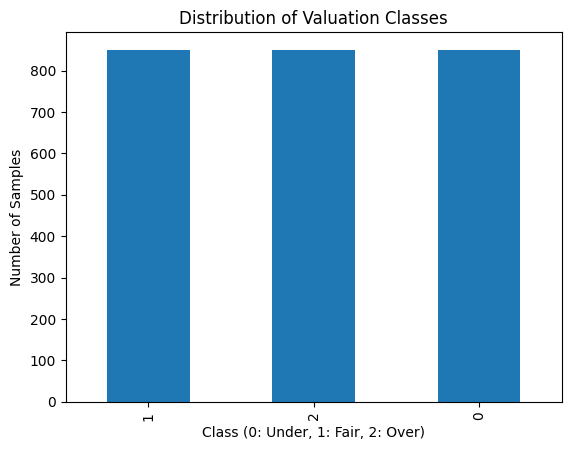

In [33]:
df = pd.read_csv('balanced_stock_data.csv')
print(df['Target'].value_counts())

# Visualize for your report
df['Target'].value_counts().plot(kind='bar', title='Distribution of Valuation Classes')
plt.xlabel('Class (0: Under, 1: Fair, 2: Over)')
plt.ylabel('Number of Samples')
plt.show()
#reduce bias is overvalued set take out remove sample classes for targets 
#use my dataset manual to check out from the data 
#1 reduce to 400-300
#varation of data  mean mode and std

In [ ]:
# List the features you want to analyze (excluding the Target itself)
# These should match the names in your CSV
analysis_features = ['PE_Ratio', 'ROE', 'Momentum', 'Volatility', 'Debt_to_Equity', 'Revenue_Growth']

print("--- DESCRIPTIVE STATISTICS BY CLASS ---")
print("Class 0: Undervalued | Class 1: Fair | Class 2: Overvalued\n")

for feat in analysis_features:
    if feat in df.columns:
        print(f"Analysis for: {feat}")
        
        # Calculate stats grouped by the Target class
        stats = df.groupby('Target')[feat].agg(['mean', 'median', 'std']).round(3)
        
        # Renaming for clarity in your report
        stats.index = ['Undervalued (0)', 'Fair (1)', 'Overvalued (2)']
        print(stats)
        print("-" * 40)

# Save this summary to a CSV so you can put it in your dissertation table
summary_table = df.groupby('Target')[analysis_features].agg(['mean', 'std']).round(3)
summary_table.to_csv('feature_variation_summary.csv')
print("\nSummary table saved to 'feature_variation_summary.csv'")# List the features you want to analyze (excluding the Target itself)
# These should match the names in your CSV
analysis_features = ['PE_Ratio', 'ROE', 'Momentum', 'Volatility', 'Debt_to_Equity', 'Revenue_Growth']

print("--- DESCRIPTIVE STATISTICS BY CLASS ---")
print("Class 0: Undervalued | Class 1: Fair | Class 2: Overvalued\n")

for feat in analysis_features:
    if feat in df.columns:
        print(f"Analysis for: {feat}")
        
        # Calculate stats grouped by the Target class
        stats = df.groupby('Target')[feat].agg(['mean', 'median', 'std']).round(3)
        
        # Renaming for clarity in your report
        stats.index = ['Undervalued (0)', 'Fair (1)', 'Overvalued (2)']
        print(stats)
        print("-" * 40)

# Save this summary to a CSV so you can put it in your dissertation table
summary_table = df.groupby('Target')[analysis_features].agg(['mean', 'std']).round(3)

print("\nSummary table saved to 'feature_variation_summary.csv'")

In [ ]:
# Filter only features that exist in the dataframe
features_to_plot = [f for f in analysis_features if f in df.columns]

if not features_to_plot:
    print("Error: None of the requested features found in the CSV.")
else:
    # UPDATED: Changed grid to 3 rows, 2 columns to fit all 6 features
    plt.figure(figsize=(16, 18)) 
    
    # Define colors for the classes
    palette = {0: 'green', 1: 'blue', 2: 'red'}
    labels = {0: 'Undervalued (Class 0)', 1: 'Fair (Class 1)', 2: 'Overvalued (Class 2)'}
    
    for i, feature in enumerate(features_to_plot):
        # UPDATED: (3 rows, 2 columns, index)
        plt.subplot(3, 2, i + 1) 
        
        # Create the bell curves (KDE plots)
        for target_val in sorted(df['Target'].unique()):
            subset = df[df['Target'] == target_val]
            sns.kdeplot(subset[feature], 
                        fill=True, 
                        label=labels.get(target_val, f'Class {target_val}'), 
                        color=palette.get(target_val, 'gray'),
                        alpha=0.4,
                        linewidth=2)
        
        plt.title(f'Bell Curve Distribution: {feature}', fontsize=14)
        plt.xlabel(f'{feature} Value', fontsize=12)
        plt.ylabel('Density', fontsize=12)
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.legend()

    plt.tight_layout()
    plt.savefig('feature_bell_curves.png')
    print("Success: Bell curves saved as feature_bell_curves.png")# Filter only features that exist in the dataframe


In [ ]:

corr_matrix = df.drop(['Ticker', 'Sector','Timestamp'], axis=1, errors='ignore').corr()

plt.figure(figsize=(12, 8)) 
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5) 
plt.title("Feature Correlation Matrix: Identifying Market Drivers") 
plt.savefig("correlation_heatmap.png") 
plt.show()

In [ ]:
# 1. Drop non-numeric columns for the correlation
numeric_df = df.select_dtypes(include=['float64', 'int64'])

# 2. Calculate the correlation specifically against the 'Target'
target_corr = numeric_df.corr()['Target'].sort_values(ascending=False)

# 3. Plotting the bar chart
plt.figure(figsize=(10, 6))
target_corr.drop('Target').plot(kind='bar', color='skyblue')
plt.title("Correlation of Independent Variables with Target (Valuation Class)")
plt.ylabel("Correlation Coefficient")
plt.axhline(0, color='black', lw=1)
plt.savefig("correlation_barchart.png")
plt.show()

In [ ]:
data, intrinsic_price = fetchStockInfo("pltr")
table_data = data.tail(5).copy()
table_data = table_data.round(3)

# 2. Create the Plot
fig, ax = plt.subplots(figsize=(14, 4)) # Adjust size for your report
ax.axis('tight')
ax.axis('off')

# 3. Create the Table
table = ax.table(cellText=table_data.values, 
                 colLabels=table_data.columns, 
                 cellLoc='center', 
                 loc='center',
                 colColours=["#f2f2f2"] * len(table_data.columns)) # Light grey header

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.7) # Scale for better spacing

plt.title("Latest Stock Feature Matrix", fontsize=14, pad=20)
plt.show()

In [34]:
# ============================================================
# DATA PREP — Fixed for honest evaluation (3 bugs patched)
# ============================================================
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold

df = pd.read_csv('balanced_stock_data.csv')
df = pd.get_dummies(df, columns=['Sector'])
# NEW: split by TICKER -> a ticker is in train OR test, never both
all_tickers  = df['Ticker'].unique()
rng          = np.random.default_rng(42)
rng.shuffle(all_tickers)
split_point  = int(len(all_tickers) * 0.70)  # 70/30 split by ticker
train_tickers = all_tickers[:split_point]
test_tickers  = all_tickers[split_point:]

train_mask = df['Ticker'].isin(train_tickers)
test_mask  = df['Ticker'].isin(test_tickers)

X = df.drop(['Target', 'Ticker', 'Timestamp'], axis=1, errors='ignore')
y = df['Target']
groups = df['Ticker']  # kept for GroupKFold in GridSearch

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]
groups_train    = groups[train_mask]

# Scale Data (Required for ANN and KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Train tickers: {len(train_tickers)} | Test tickers: {len(test_tickers)}")
print(f"Train rows: {len(X_train)} | Test rows: {len(X_test)}")
print(f"Training on {len(X.columns)} features: {X.columns.tolist()}")
print(f"\nTest set class balance:\n{y_test.value_counts().sort_index()}")

Train tickers: 109 | Test tickers: 47
Train rows: 1748 | Test rows: 802
Training on 21 features: ['PE_Ratio', 'ROE', 'ROA', 'EPS', 'Dividend_Yield', 'Debt_to_Equity', 'Price_to_Book', 'Price_to_Sales', 'Revenue_Growth', 'Operating_Margin', 'Momentum', 'Volatility', 'sp500_close', 'Sector_Discretionary', 'Sector_Energy', 'Sector_Financials', 'Sector_Healthcare', 'Sector_Industrials', 'Sector_Staples', 'Sector_Technology', 'Sector_Utilities']

Test set class balance:
Target
0    253
1    288
2    261
Name: count, dtype: int64


In [35]:
# --- FIX 3: cap max_depth (50 was memorising) + use GroupKFold so the same
# ticker never appears in both the CV train and validation fold ---
from sklearn.model_selection import GroupKFold

param_rf = {
    'n_estimators': [100, 300],
    'max_depth': [5, 10, 15]   # removed 50 — way too deep for 1311 rows
}
group_cv = GroupKFold(n_splits=5)
rf_model = RandomForestClassifier(random_state=42, class_weight='balanced')
grid_rf  = GridSearchCV(rf_model, param_rf, cv=group_cv, n_jobs=-1)
grid_rf.fit(X_train, y_train, groups=groups_train)
y_pred_rf = grid_rf.predict(X_test)

print(f"Best Params: {grid_rf.best_params_}")
print(classification_report(y_test, y_pred_rf))

Best Params: {'max_depth': 15, 'n_estimators': 100}
              precision    recall  f1-score   support

           0       0.73      0.60      0.66       253
           1       0.67      0.42      0.52       288
           2       0.57      0.91      0.70       261

    accuracy                           0.63       802
   macro avg       0.66      0.64      0.62       802
weighted avg       0.66      0.63      0.62       802



In [36]:
param_xgb = {
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 200],
    'max_depth': [3, 4],
    'subsample': [0.8],
    'colsample_bytree': [0.6]
}

xgb_model = XGBClassifier(
    eval_metric='mlogloss',
    random_state=42,
    reg_lambda=1
)
# Use GroupKFold so the same ticker never leaks across CV folds
group_cv  = GroupKFold(n_splits=5)
grid_xgb  = GridSearchCV(xgb_model, param_xgb, cv=group_cv, n_jobs=-1)
grid_xgb.fit(X_train, y_train, groups=groups_train)
y_pred_xgb = grid_xgb.predict(X_test)

print(f"Best Params: {grid_xgb.best_params_}")
print(classification_report(y_test, y_pred_xgb))

Best Params: {'colsample_bytree': 0.6, 'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 100, 'subsample': 0.8}
              precision    recall  f1-score   support

           0       0.65      0.73      0.69       253
           1       0.57      0.42      0.49       288
           2       0.67      0.78      0.72       261

    accuracy                           0.64       802
   macro avg       0.63      0.65      0.63       802
weighted avg       0.63      0.64      0.63       802



In [15]:

param_ann = {
    'hidden_layer_sizes': [(64, 32), (100,)],
    'alpha': [0.0001, 0.05]
}
group_cv  = GroupKFold(n_splits=5)
grid_ann  = GridSearchCV(MLPClassifier(max_iter=1000, random_state=42), param_ann, cv=group_cv, n_jobs=-1)
grid_ann.fit(X_train_scaled, y_train, groups=groups_train)
y_pred_ann = grid_ann.predict(X_test_scaled)

print(f"Best Params: {grid_ann.best_params_}")
print(classification_report(y_test, y_pred_ann))

Best Params: {'alpha': 0.05, 'hidden_layer_sizes': (100,)}
              precision    recall  f1-score   support

           0       0.62      0.56      0.59       113
           1       0.46      0.42      0.44       126
           2       0.63      0.74      0.68       129

    accuracy                           0.57       368
   macro avg       0.57      0.57      0.57       368
weighted avg       0.57      0.57      0.57       368



C:\Users\TheSa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


In [16]:
param_knn = {
    'n_neighbors': [3, 7, 15],
    'weights': ['uniform', 'distance']
}
group_cv  = GroupKFold(n_splits=5)
grid_knn  = GridSearchCV(KNeighborsClassifier(), param_knn, cv=group_cv, n_jobs=-1)
grid_knn.fit(X_train_scaled, y_train, groups=groups_train)
y_pred_knn = grid_knn.predict(X_test_scaled)

print(f"Best Params: {grid_knn.best_params_}")
print(classification_report(y_test, y_pred_knn))

Best Params: {'n_neighbors': 15, 'weights': 'distance'}
              precision    recall  f1-score   support

           0       0.56      0.56      0.56       113
           1       0.48      0.44      0.46       126
           2       0.62      0.68      0.65       129

    accuracy                           0.56       368
   macro avg       0.55      0.56      0.56       368
weighted avg       0.56      0.56      0.56       368



In [ ]:
# 1. Evaluate the Best Model found by GridSearch
best_rf = grid_rf.best_estimator_
importances = best_rf.feature_importances_
feature_names = X.columns

# Create a DataFrame to view them clearly
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("\n--- Feature Ranking for your Model ---")
print(importance_df)
y_pred_rf = best_rf.predict(X_test)

# 2. Simple Performance Printout
print("--- MODEL BACKTEST RESULTS ---")
print(f"Best Parameters: {grid_rf.best_params_}")
print(f"Overall Accuracy: {accuracy_score(y_test, y_pred_rf):.2%}")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_rf))

# 3. Simple Visual: Confusion Matrix
# This shows exactly where the model "disagrees" with the Graham Formula
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Undervalued', 'Fair', 'Overvalued'],
            yticklabels=['Undervalued', 'Fair', 'Overvalued'])
plt.xlabel('Model Prediction')
plt.ylabel('Actual Graham Label')
plt.title('Backtest: Prediction vs. Reality')
plt.show()

In [37]:
test_tickers = [
    # --- THE TECH GIANTS (High PE, High Growth) ---
    "NVDA", # Nvidia: Extreme growth vs low book value.
    "MSFT", # Microsoft: Massive quality premiums.
    "AAPL",# Apple: High ROE, but expensive by Graham math.
    "TSLA",
    "SNOW",
    "CAT",
    "JNJ",
    
    
    # --- THE SPECULATIVE & VOLATILE ---
    "COIN", # Coinbase: High volatility, fluctuates wildy from Graham's anchor.
    "PLTR", # Palantir: Data/AI growth play with non-traditional financials.
    
    # --- THE VALUE TRAPS / DEBT HEAVY ---
    "T",    # AT&T: High debt, low growth. Will AI call it overvalued despite low price?
    "F",    # Ford: Classic industrial. Does AI agree with the low Graham valuation?
    "BA",   # Boeing: High debt and operational issues.
    
    # --- THE CONSISTENT QUALITY (AI should love these) ---
    "COST", # Costco: High PE usually, but incredible efficiency/ROE.
    "V",    # Visa: Asset-light, ultra-high margins.
    "PG",   # Procter & Gamble: Defensive, steady metrics.
    
    # --- THE RECOVERY / TRANSITION PLAYS ---
    "DIS",  # Disney: Moving from legacy to streaming growth.
    "INTC", # Intel: Struggling legacy tech. A test of "Momentum" vs "Value."
    
    # --- THE "STRICT VALUE" PLAYS ---
    "BRK-B",# Berkshire Hathaway: The king of value.
    "JPM" , "XOM", "CVX", "COP", "OXY", "DVN", "MRO", "HAL", "SLB", "PSX", "VLO",
    "MPC", "HES", "EOG", "PXD", "BP", "SHEL", "TTE", "E", "EC", "YPF",

    # --- FINANCIALS (low P/B, decent ROE, your Graham formula works here) ---
    "JPM", "BAC", "WFC", "C", "USB", "PNC", "TFC", "CFG", "KEY", "HBAN",
    "RF", "FITB", "MTB", "ZION", "FHN", "BEN", "IVZ", "GS", "MS", "MET",

    # --- INDUSTRIALS (steady earnings, real assets) ---
    "GE", "HON", "MMM", "CAT", "DE", "EMR", "ETN", "PH", "ITW", "DOV",
    "ROK", "IR", "CARR", "TXT", "LMT", "NOC", "RTX", "GD", "HII", "BWA",

    # --- HEALTHCARE / PHARMA (strong EPS, beaten down valuations) ---
    "JNJ", "PFE", "MRK", "ABBV", "BMY", "GILD", "CVS", "CI", "HUM", "CNC",
    "MOH", "AMGN", "BIIB", "VTRS", "OGN", "JAZZ", "PBH", "PRGO", "ENR", "BCO",

    # --- STAPLES (consistent EPS, dividends, model likes dividend yield) ---
    "KO", "PEP", "KHC", "MO", "BTI", "GIS", "K", "CPB", "CAG", "SJM",
    "HRL", "TSN", "PG", "CL", "CHD", "SPB", "CENT", "COTY", "KR", "SFM",

    # --- BEATEN DOWN / LOW P/E ---
    "INTC", "BA", "T", "VZ", "DIS", "WBD", "PARA", "F", "GM", "STLA",  # JPMorgan: Financial sector test for the Graham Formula.
]
print("\n--- FINAL AI VALIDATION (Clean & Bulletproof) ---")

for ticker in test_tickers:
    try:
        # 1. Fetch RAW data for Graham Math and Price
        t = yf.Ticker(ticker)
        info = t.info
        # Get just the very last price point
        hist = t.history(period="1d")
        if hist.empty: continue
        current_price = hist['Close'].iloc[-1]
        
        # 2. Get AI Features and Graham Value from your function
        # (df_live contains only the columns the AI needs)
        pe_ratio = info.get('trailingPE', 0)
        df_live, g_val = fetchStockInfo(ticker)
        if df_live.empty: continue
        
        # 3. Create Template Row (Must match X_train columns exactly)
        input_row = pd.DataFrame(0.0, index=[0], columns=X.columns)
        
        # 4. Fill Features (using the most recent row from fetchStockInfo)
        latest_data = df_live.iloc[-1]
        for col in X.columns:
            if col in latest_data:
                input_row.loc[0, col] = float(latest_data[col])
            # Handle Sector columns (One-Hot Encoding)
            elif col.startswith('Sector_'):
                sector_name = latest_data.get('Sector', 'Unknown')
                if col == f"Sector_{sector_name}":
                    input_row.loc[0, col] = 1.0

        # 5. Scale and Predict
       
        ai_idx = grid_xgb.predict(input_row)[0]
        
        # 6. Graham Label Logic
        if current_price < (g_val * 0.9): formula_idx = 0
        elif current_price > (g_val * 1.1): formula_idx = 2
        else: formula_idx = 1
        
        # Mapping
        labels = {0: "Undervalued", 1: "Fair", 2: "Overvalued"}
        
        print(f"STOCK: {ticker: <5} | Price: {current_price: >7.2f} |  P/E: {pe_ratio: >7.2f} | Graham: {g_val: >7.2f}")
        print(f"  > Graham Says: {labels[formula_idx]}")
        print(f"  > AI Says:     {labels[ai_idx]}")
        
        if formula_idx != ai_idx:
            print("  *** DISRUPTION DETECTED ***")
        print("-" * 45)
            
    except Exception as e:
        print(f"Error testing {ticker}: {e}")


--- FINAL AI VALIDATION (Clean & Bulletproof) ---
STOCK: NVDA  | Price:  184.77 |  P/E:   37.71 | Graham:   26.71
  > Graham Says: Overvalued
  > AI Says:     Fair
  *** DISRUPTION DETECTED ***
---------------------------------------------
STOCK: MSFT  | Price:  405.76 |  P/E:   25.38 | Graham:  137.58
  > Graham Says: Overvalued
  > AI Says:     Fair
  *** DISRUPTION DETECTED ***
---------------------------------------------
STOCK: AAPL  | Price:  260.83 |  P/E:   33.02 | Graham:   32.65
  > Graham Says: Overvalued
  > AI Says:     Fair
  *** DISRUPTION DETECTED ***
---------------------------------------------
STOCK: TSLA  | Price:  399.23 |  P/E:  369.66 | Graham:   23.07
  > Graham Says: Overvalued
  > AI Says:     Overvalued
---------------------------------------------
  SNOW: computed P/E manually (-44.4975)
STOCK: SNOW  | Price:  175.32 |  P/E:    0.00 | Graham:   22.32
  > Graham Says: Overvalued
  > AI Says:     Overvalued
---------------------------------------------
STOCK:

$MRO: possibly delisted; no price data found  (period=1d) (Yahoo error = "No data found, symbol may be delisted")


STOCK: HAL   | Price:   35.34 |  P/E:   23.56 | Graham:   20.56
  > Graham Says: Overvalued
  > AI Says:     Overvalued
---------------------------------------------
STOCK: SLB   | Price:   48.11 |  P/E:   20.47 | Graham:   30.38
  > Graham Says: Overvalued
  > AI Says:     Overvalued
---------------------------------------------
STOCK: PSX   | Price:  162.50 |  P/E:   15.06 | Graham:  132.69
  > Graham Says: Overvalued
  > AI Says:     Overvalued
---------------------------------------------
STOCK: VLO   | Price:  217.02 |  P/E:   28.67 | Graham:  116.27
  > Graham Says: Overvalued
  > AI Says:     Overvalued
---------------------------------------------
STOCK: MPC   | Price:  215.23 |  P/E:   16.28 | Graham:  132.13
  > Graham Says: Overvalued
  > AI Says:     Overvalued
---------------------------------------------


HTTP Error 404: 
$HES: possibly delisted; no price data found  (period=1d) (Yahoo error = "No data found, symbol may be delisted")


STOCK: EOG   | Price:  127.89 |  P/E:   14.02 | Graham:  106.70
  > Graham Says: Overvalued
  > AI Says:     Overvalued
---------------------------------------------


...

STOCK: BP    | Price:   39.94 |  P/E: 1997.00 | Graham:    1.25
  > Graham Says: Overvalued
  > AI Says:     Overvalued
---------------------------------------------
STOCK: SHEL  | Price:   85.11 |  P/E:   14.19 | Graham:   64.05
  > Graham Says: Overvalued
  > AI Says:     Overvalued
---------------------------------------------
STOCK: TTE   | Price:   80.08 |  P/E:   13.85 | Graham:   83.50
  > Graham Says: Fair
  > AI Says:     Fair
---------------------------------------------
STOCK: E     | Price:   48.36 |  P/E:   26.87 | Graham:   27.53
  > Graham Says: Overvalued
  > AI Says:     Overvalued
---------------------------------------------
  Skipping EC: Price to Sales cannot be computed.
Error testing EC: 'NoneType' object has no attribute 'empty'
  YPF: computed P/E manually (-17.3839)
STOCK: YPF   | Price:   36.68 |  P/E:    0.00 | Graham:   36.56
  > Graham Says: Fair
  > AI Says:     Overvalued
  *** DISRUPTION DETECTED ***
---------------------------------------------
STOCK: 

HTTP Error 404: 
$K: possibly delisted; no price data found  (period=1d) (Yahoo error = "No data found, symbol may be delisted")


STOCK: CPB   | Price:   24.68 |  P/E:   12.72 | Graham:   24.08
  > Graham Says: Fair
  > AI Says:     Undervalued
  *** DISRUPTION DETECTED ***
---------------------------------------------
  CAG: computed P/E manually (-86.0952)
STOCK: CAG   | Price:   18.08 |  P/E:    0.00 | Graham:    8.94
  > Graham Says: Overvalued
  > AI Says:     Overvalued
---------------------------------------------
  SJM: computed P/E manually (-9.2002)
STOCK: SJM   | Price:  108.47 |  P/E:    0.00 | Graham:  114.10
  > Graham Says: Fair
  > AI Says:     Overvalued
  *** DISRUPTION DETECTED ***
---------------------------------------------
STOCK: HRL   | Price:   23.34 |  P/E:   26.22 | Graham:   17.00
  > Graham Says: Overvalued
  > AI Says:     Overvalued
---------------------------------------------
STOCK: TSN   | Price:   60.24 |  P/E:  107.57 | Graham:   25.40
  > Graham Says: Overvalued
  > AI Says:     Overvalued
---------------------------------------------
STOCK: PG    | Price:  156.01 |  P/E:   23

HTTP Error 404: 
$PARA: possibly delisted; no price data found  (period=1d) (Yahoo error = "No data found, symbol may be delisted")


  F: computed P/E manually (-5.9417)
STOCK: F     | Price:   12.24 |  P/E:    0.00 | Graham:   20.44
  > Graham Says: Undervalued
  > AI Says:     Undervalued
---------------------------------------------
STOCK: GM    | Price:   74.93 |  P/E:   22.91 | Graham:   70.53
  > Graham Says: Fair
  > AI Says:     Undervalued
  *** DISRUPTION DETECTED ***
---------------------------------------------
  STLA: computed P/E manually (-0.7727)
STOCK: STLA  | Price:    6.90 |  P/E:    0.00 | Graham:   65.68
  > Graham Says: Undervalued
  > AI Says:     Undervalued
---------------------------------------------


<Figure size 1000x600 with 0 Axes>

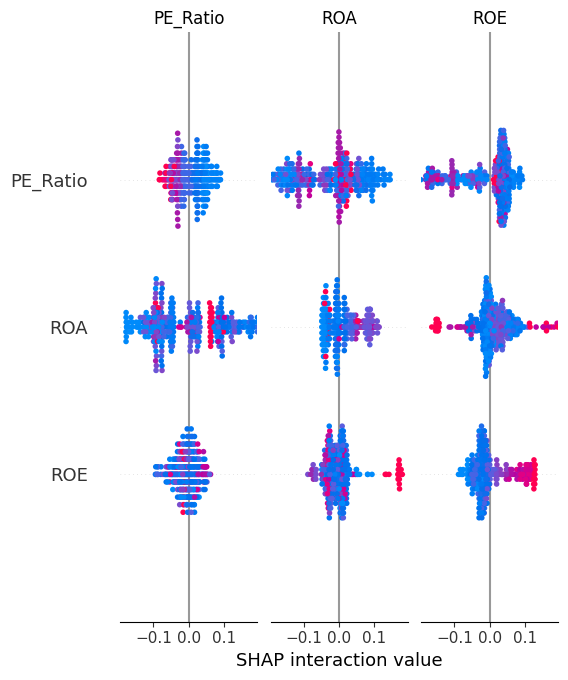

In [18]:
import shap
import matplotlib.pyplot as plt

# 1. Get the best model
rf_best = grid_rf.best_estimator_ 

# 2. Re-initialize explainer
rf_explainer = shap.TreeExplainer(rf_best)
# 2. Initialize the Explainer
# We use 'X_test' as the data to explain
explainer = shap.TreeExplainer(rf_best)
shap_values = explainer.shap_values(X_test)

# 3. Create the Summary Plot
# This "Beeswarm" plot is the gold standard for AI research
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test)

In [ ]:


# We wrap it in an Explanation object so SHAP can read it easily
# shap_values[..., 0] or shap_values[0] depending on your XGBoost version
# Let's try the most robust way:
class_0_values = shap_values[..., 0] if len(shap_values.shape) == 3 else shap_values[0]

shap.summary_plot(class_0_values, X_test, plot_type="bar")



In [ ]:
# Explaining the very first stock in your test set
stock_to_explain = 0 
class_to_explain = 0 # 0=Under, 1=Fair, 2=Over

# 3. Create the Explanation object correctly
exp = shap.Explanation(
    values=shap_values[stock_to_explain, :, class_to_explain], 
    base_values=explainer.expected_value[class_to_explain], 
    data=X_test.iloc[stock_to_explain], 
    feature_names=X_test.columns
)

# 4. Plot
plt.figure(figsize=(10, 6))
shap.plots.waterfall(exp)
plt.show()


In [38]:
import joblib

# Save model as JSON
grid_xgb.best_estimator_.get_booster().save_model('valuation_model_xgb.json')

# Resave columns — must match new Market_Regime encoded columns
joblib.dump(list(X_train.columns), 'model_columns.pkl')

# Verify both
import os
print("JSON exists:", os.path.exists('valuation_model_xgb.json'))
print("PKL exists:", os.path.exists('model_columns.pkl'))
print("Columns saved:", list(X_train.columns))


JSON exists: True
PKL exists: True
Columns saved: ['PE_Ratio', 'ROE', 'ROA', 'EPS', 'Dividend_Yield', 'Debt_to_Equity', 'Price_to_Book', 'Price_to_Sales', 'Revenue_Growth', 'Operating_Margin', 'Momentum', 'Volatility', 'sp500_close', 'Sector_Discretionary', 'Sector_Energy', 'Sector_Financials', 'Sector_Healthcare', 'Sector_Industrials', 'Sector_Staples', 'Sector_Technology', 'Sector_Utilities']
